# Player profile — Serhou Guirassy

**Player-centric** BSQ view for Borussia Dortmund (Dortmund vs Stuttgart). Only **2 shots** in the five-match sample — interpret means with that small-n caveat. **Finishing execution index** ranks highly in the cohort (see leaderboard notebook).


In [1]:
# Run stamp — you should see this text below after selecting kernel BSQ Hackathon (.venv)
from datetime import datetime, timezone
import plotly.io as pio
from aws_football.bsq_reports import use_bsq_notebook_plotly

renderer = use_bsq_notebook_plotly()
print("=" * 60)
print("PLAYER PROFILE NOTEBOOK")
print("Executed:", datetime.now(timezone.utc).strftime("%Y-%m-%d %H:%M UTC"))
print("Plotly renderer:", renderer)
print("If charts below are empty: Kernel -> BSQ Hackathon (.venv), then Reload from Disk")
print("=" * 60)


PLAYER PROFILE NOTEBOOK
Executed: 2026-05-27 10:46 UTC
Plotly renderer: vscode
If charts below are empty: Kernel -> BSQ Hackathon (.venv), then Reload from Disk


In [2]:
from pathlib import Path
from IPython.display import HTML, display
import pandas as pd
from aws_football.bsq_reports import (
    merge_shot_tables,
    player_summary,
    display_plotly_player_dashboard,
    display_plotly_speedometer,
    display_plotly_phase_speedometer,
    display_player_speedometers,
    notebook_plot_style_html,
    BACKSWING_PHASE_LABEL,
    FOLLOW_THROUGH_PHASE_LABEL,
    FINISHING_EXECUTION_INDEX_COL,
)

display(HTML(notebook_plot_style_html()))
PLAYER = 'Serhou Guirassy'
df = merge_shot_tables()
guirassy = df[df.player_name == PLAYER].copy()
guirassy[['match_folder','family','shot_result', FINISHING_EXECUTION_INDEX_COL,'technique_mechanics_score','placement_score','strike_quality_score','P3_score','P4_score','P5_score']]


,match_folder,family,shot_result,finishing_execution_index,technique_mechanics_score,placement_score,strike_quality_score,P3_score,P4_score,P5_score
30,Dortmund_Stuttgart,header,shotWide,64.023660,48.690138,62.864067,NaN,45.549863,22.783329,92.756767
40,Dortmund_Stuttgart,open_play,savedShot,93.253968,NaN,35.413272,NaN,68.201397,61.305430,92.508609


In [3]:
means = player_summary(df, PLAYER)
show = [FINISHING_EXECUTION_INDEX_COL,'technique_mechanics_score','placement_score','strike_quality_score','P3_score','P4_score','P5_score']
pd.DataFrame({'metric': show, 'mean_score': [round(means[c],1) for c in show]})


,metric,mean_score
0,finishing_execution_index,78.6
1,technique_mechanics_score,48.7
2,placement_score,49.1
3,strike_quality_score,NaN
4,P3_score,56.9
5,P4_score,42.0
6,P5_score,92.6


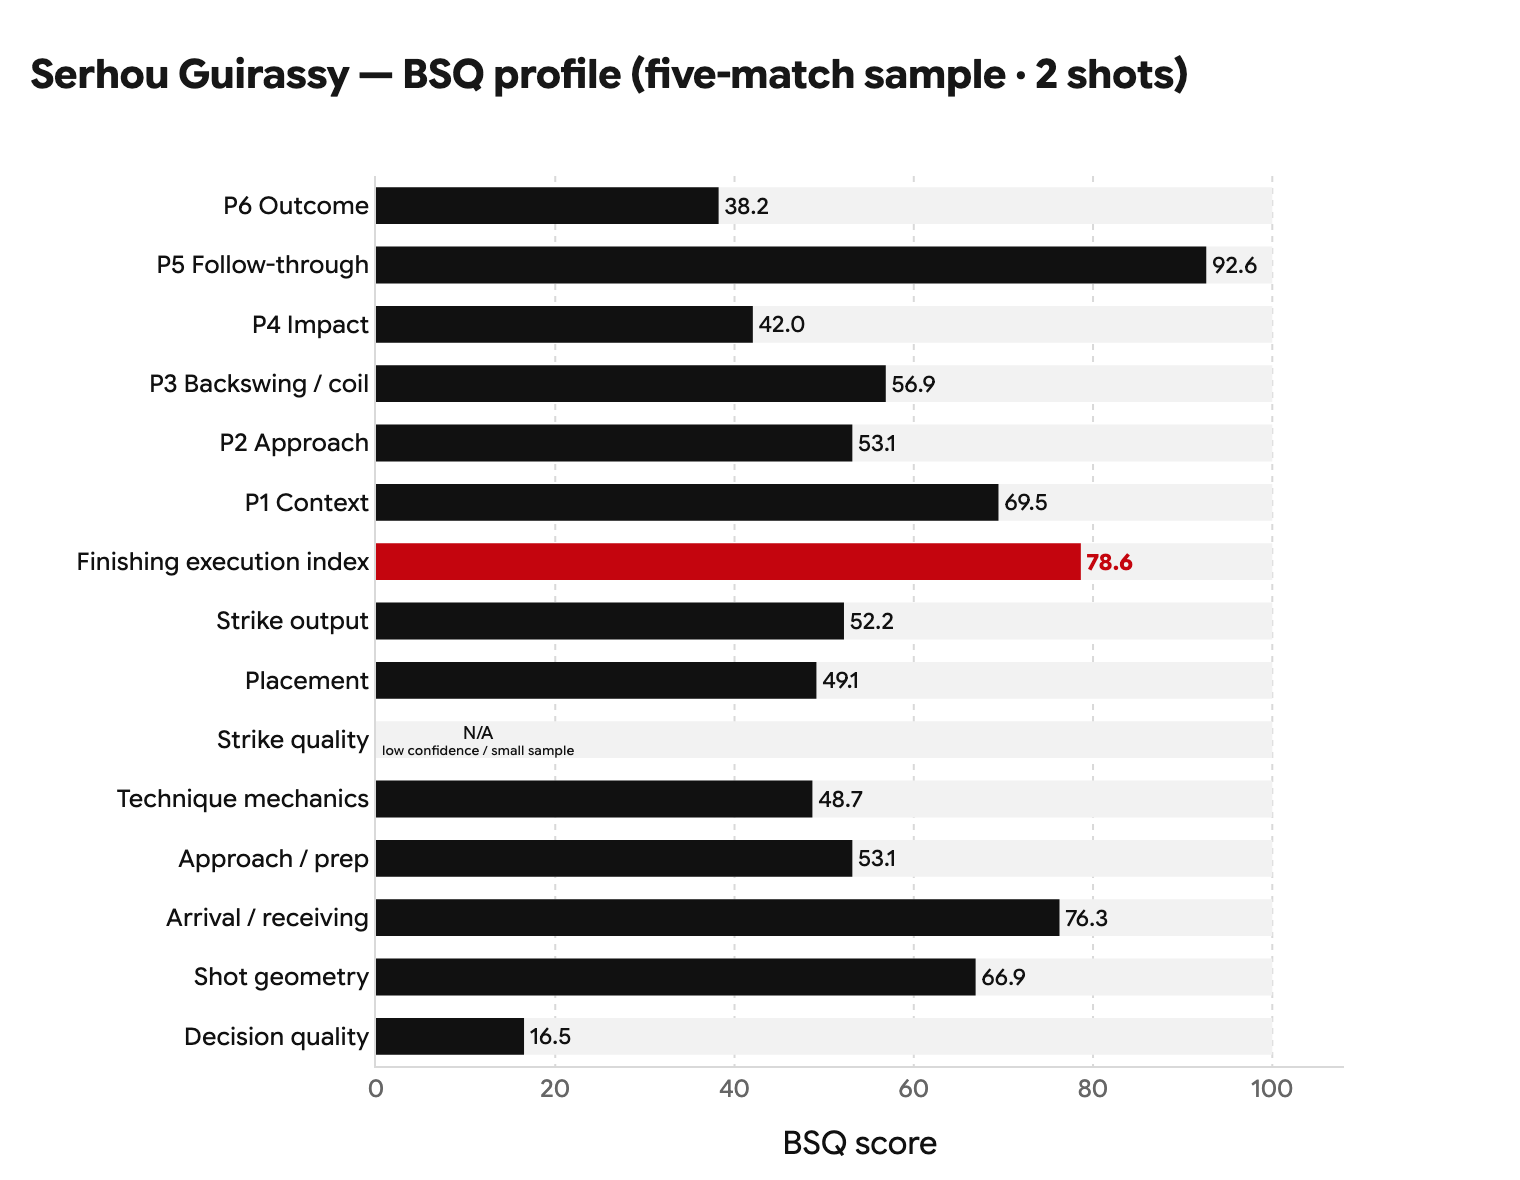

In [4]:
display_plotly_player_dashboard(means, PLAYER, n_shots=len(guirassy))


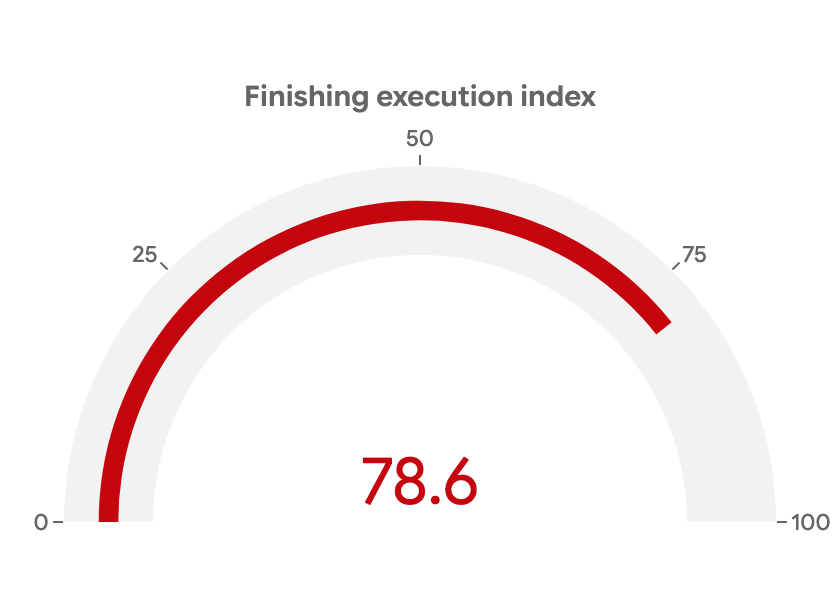

In [5]:
display_plotly_speedometer('Finishing execution index', means['finishing_execution_index'])


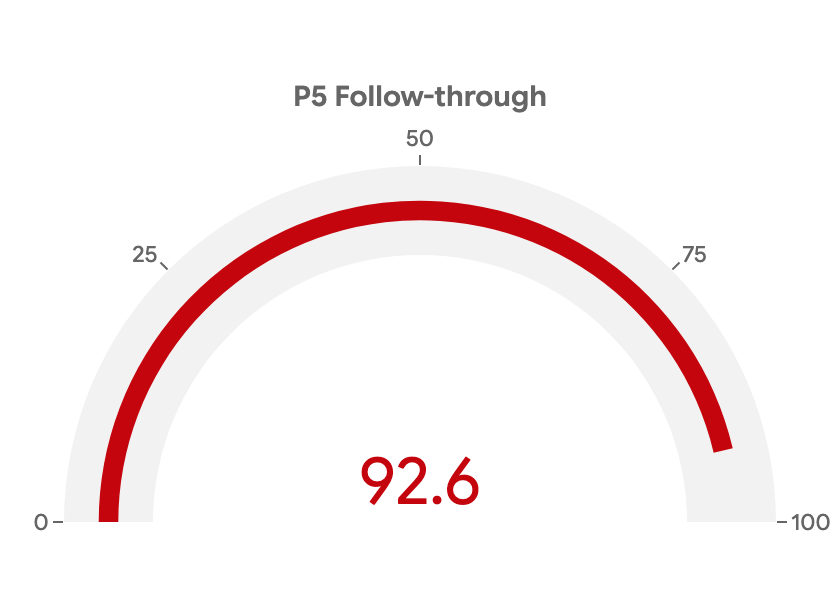

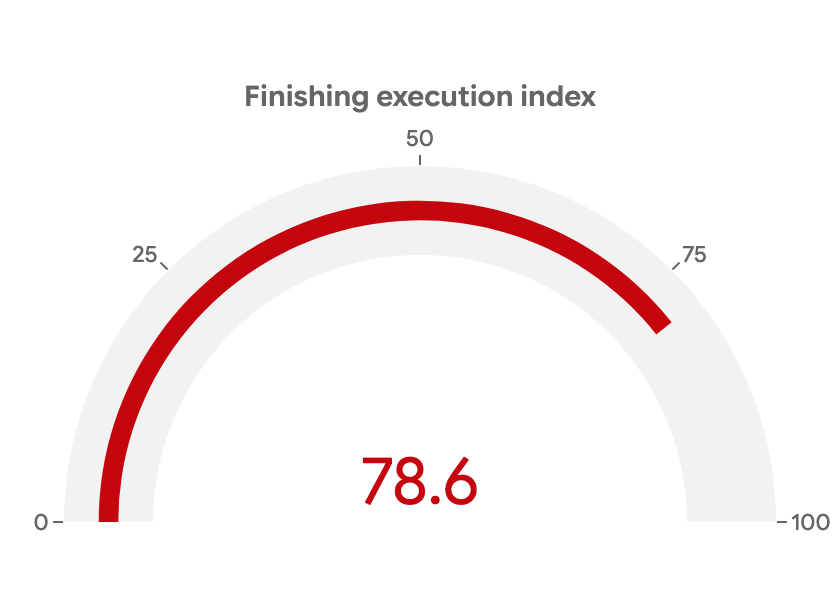

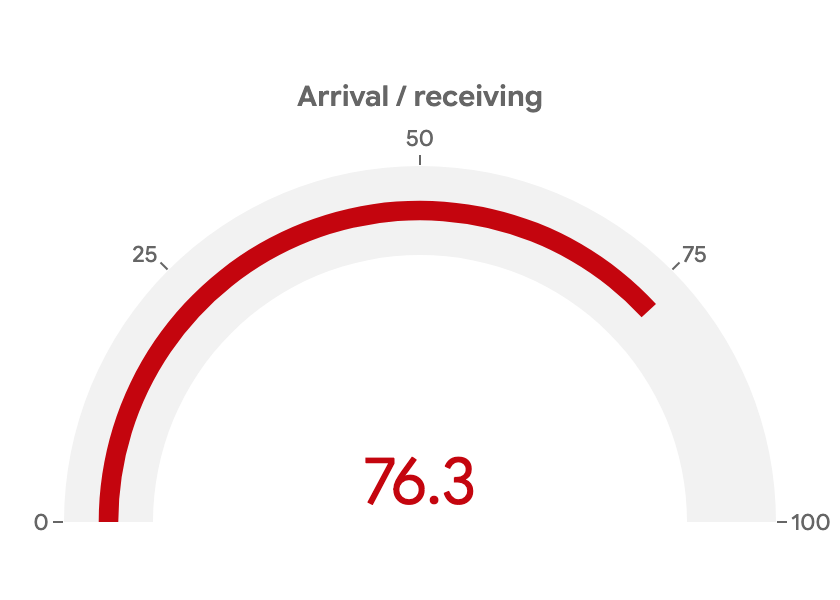

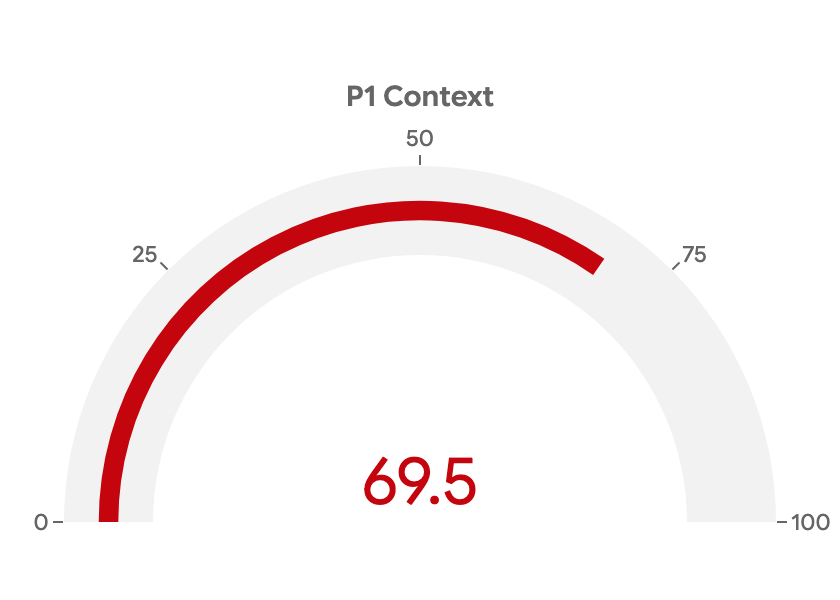

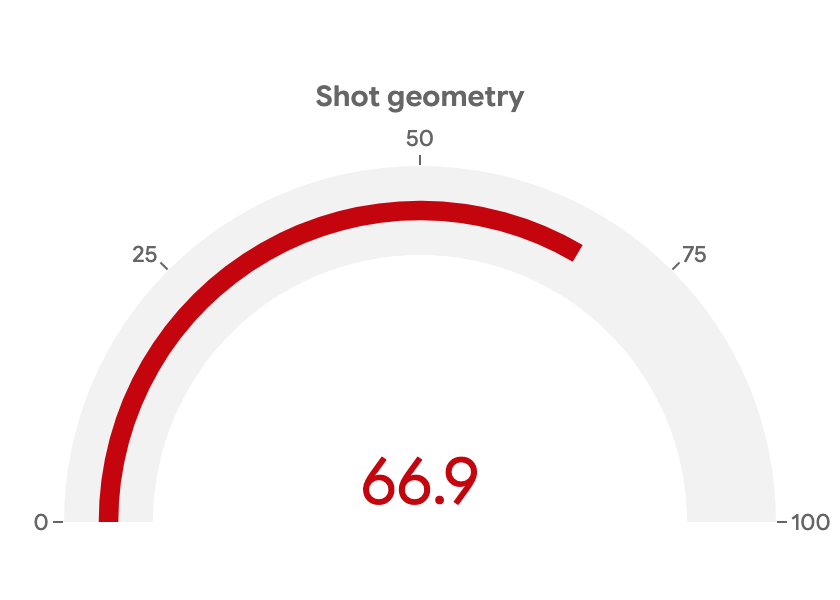

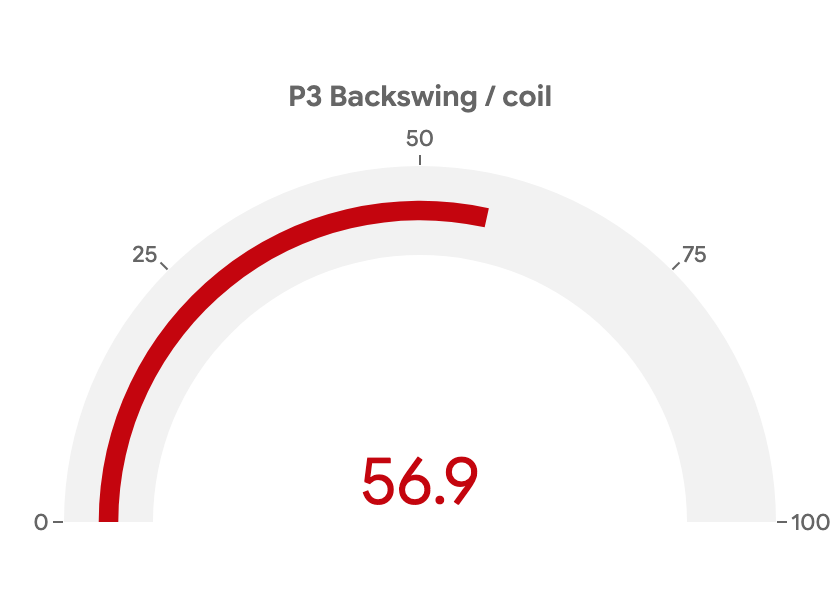

[('P5 Follow-through', 92.6326884019562),
 ('Finishing execution index', 78.6388140161725),
 ('Arrival / receiving', 76.25833333333334),
 ('P1 Context', 69.45112485134058),
 ('Shot geometry', 66.89880012825972),
 ('P3 Backswing / coil', 56.875629696567835)]

In [6]:
highlights = display_player_speedometers(means, min_score=55, top_n=10)
highlights


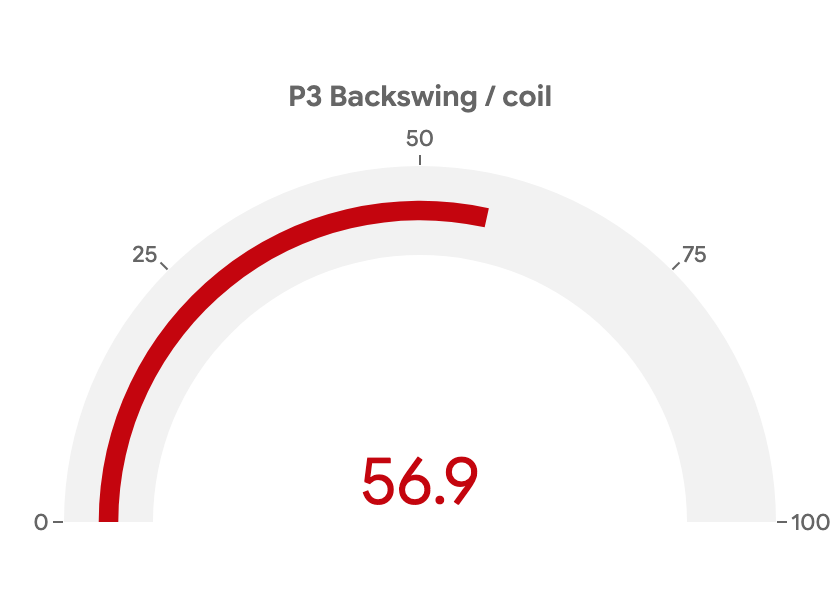

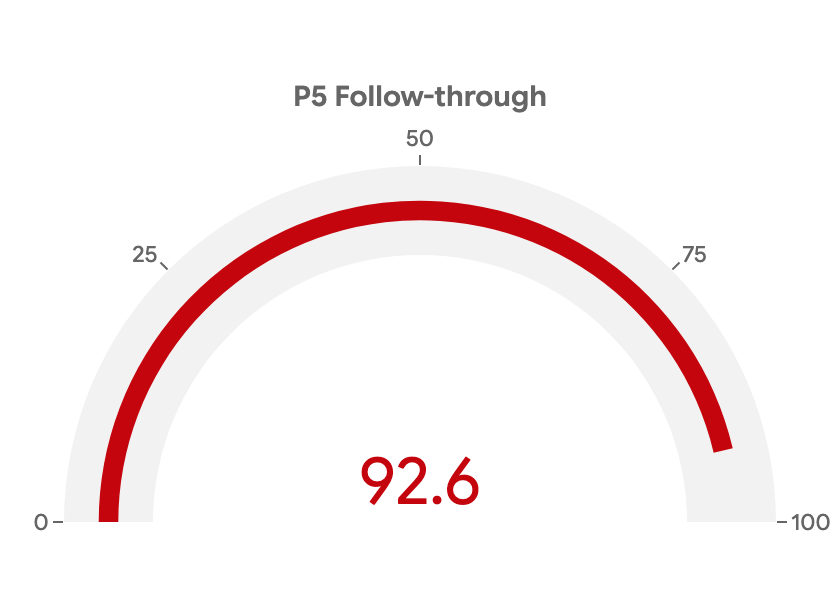

In [7]:
display_plotly_phase_speedometer(means, BACKSWING_PHASE_LABEL)
display_plotly_phase_speedometer(means, FOLLOW_THROUGH_PHASE_LABEL)


### Interpretation (sample)

Across **2 shots** (header wide, open-play saved), Guirassy’s **finishing execution index** averages in the upper cohort (~**79**), driven by strong post-strike execution on the saved attempt. Technique mechanics reflect the header only (~**49**); placement splits a stronger header geometry vs a lower open-play placement score. Use this profile alongside raw shot rows above — not as a full-season rating.
